# Audit Portabilitas dan Reproduksibilitas IHSG
## Notebook "Berjalan Sendiri" di Kaggle

Notebook ini memperbaiki masalah portabilitas dan membuktikan reproduksibilitas
eksperimen **CNN-BiGRU** dan **CNN-BiGRU-*Attention*** untuk mengklasifikasikan
arah penutupan IHSG pada hari perdagangan berikutnya.

\\[
y_{t+1}=1\\;\\text{jika}\\;Close_{t+1}>Close_t,\\quad 0\\;\\text{selainnya}
\\]

Keputusan desain memakai distribusi hasil lima *seed*, bukan skor tertinggi satu
percobaan. Aspek yang dinilai ialah akurasi, simpangan baku, F1, AUC, waktu
pelatihan, jumlah parameter, kestabilan prediksi, bobot *Attention*, dan
interpretabilitas.

Notebook memakai jalur relatif, mencatat SHA-256 dataset, lingkungan, perangkat,
parameter, waktu, metrik, status, dan *checkpoint*. Lima *seed* dipakai untuk
mengukur kestabilan. Satu *seed* dijalankan ulang untuk memeriksa apakah hasil
identik pada data dan lingkungan yang sama.

**Petunjuk Kaggle:** unggah notebook ini ke [Kaggle Code](https://www.kaggle.com/code),
aktifkan **Internet**, pilih GPU bila tersedia, lalu pilih **Restart Session**
dan **Run All**. Jika Internet dimatikan, tambahkan CSV IHSG sebagai *input*.
Semua hasil tersimpan relatif terhadap folder kerja dalam `ihsg_repro_outputs`.

> Materi penelitian ini bukan rekomendasi investasi.

# Tahap 1. Algoritma Program

1. Tetapkan konfigurasi, lima *seed*, dan ambang keputusan.
2. Tetapkan jalur relatif dan catat lingkungan komputasi yang aktif.
3. Ambil OHLCV IHSG, validasi kualitas, lalu hitung SHA-256 dataset.
4. Bentuk fitur teknikal hanya dari hari \\(t\\) dan masa lalu.
5. Bentuk target arah harga pada \\(t+1\\), lalu audit hubungan tanggal.
6. Bagi data kronologis menjadi latih 70%, validasi 15%, dan uji 15%.
7. Latih normalisasi hanya pada data latih dan bentuk tensor 30 hari.
8. Latih dua model pada lima *seed* memakai kontrol yang sama.
9. Simpan *checkpoint* terbaik dan satu baris log setiap percobaan.
10. Hitung rata-rata, simpangan baku, rentang, stabilitas, dan biaya.
11. Pilih arsitektur hanya dengan validasi, lalu konfirmasi pada data uji.
12. Jalankan ulang *seed* yang sama dan bandingkan hash prediksi.
13. Susun memo integritas, register bug, manifest, dan arsip hasil.

*Attention* dipertahankan hanya jika kenaikan rata-rata akurasi minimal 0,5 poin
persentase, menang sekurangnya empat *seed*, rasio simpangan baku tidak melebihi
1,15, rasio waktu tidak melebihi 1,50, dan skor interpretabilitas tidak menurun.

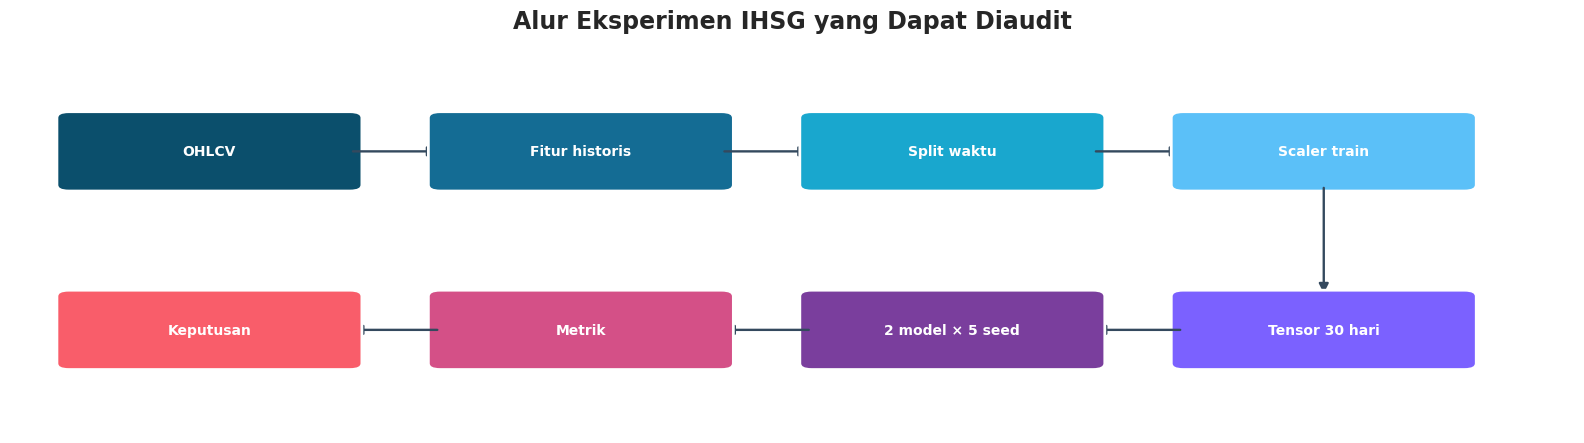

In [7]:
# Output Tahap 1: diagram alur algoritma
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

labels = ["OHLCV", "Fitur historis", "Split waktu", "Scaler train",
          "Tensor 30 hari", "2 model × 5 seed", "Metrik", "Keputusan"]
colors = ["#0B4F6C","#146C94","#19A7CE","#5BC0F8",
          "#7B61FF","#7A3E9D","#D45087","#F95D6A"]
pos = [(0.15,1.25),(1.10,1.25),(2.05,1.25),(3.00,1.25),
       (3.00,.35),(2.05,.35),(1.10,.35),(.15,.35)]
fig, ax = plt.subplots(figsize=(16,4.6))
ax.set(xlim=(0,4), ylim=(0,2)); ax.axis("off")
for i, ((x,y), lab, col) in enumerate(zip(pos,labels,colors)):
    ax.add_patch(FancyBboxPatch((x,y),.72,.34,boxstyle="round,pad=.03",
                 facecolor=col,edgecolor="white",linewidth=2))
    ax.text(x+.36,y+.17,lab,ha="center",va="center",color="white",
            fontsize=10,fontweight="bold")
    if i < 7:
        x2,y2=pos[i+1]
        if i<3: a,b=(x+.72,y+.17),(x2,y2+.17)
        elif i==3: a,b=(x+.36,y),(x2+.36,y2+.34)
        else: a,b=(x,y+.17),(x2+.72,y2+.17)
        ax.add_patch(FancyArrowPatch(a,b,arrowstyle="-|>",mutation_scale=14,
                     color="#34495E",linewidth=1.7))
ax.set_title("Alur Eksperimen IHSG yang Dapat Diaudit",fontsize=17,fontweight="bold")
plt.tight_layout(); plt.show()

# Tahap 2. *Pseudocode*

```text
MULAI
  SEEDS <- [11, 23, 37, 53, 71]
  ROOT <- folder kerja saat ini
  INPUT <- ../input
  OUTPUT <- ihsg_repro_outputs
  catat versi paket, sistem operasi, perangkat, CUDA, dan cuDNN
  ambil dan urutkan OHLCV IHSG
  hitung SHA256(dataset kanonis)
  hitung fitur dari informasi sampai hari t
  buat target arah harga pada t+1
  audit tanggal target, split, scaler, dan tensor
  split kronologis 70:15:15
  fit scaler hanya pada train
  buat sequence 30 hari
  UNTUK setiap seed:
    latih CNN-BiGRU dan CNN-BiGRU-Attention pada kontrol sama
    simpan checkpoint bobot terbaik
    simpan waktu, seed, versi, perangkat, hash, parameter, metrik, status
    simpan bobot Attention dari validasi
  hitung mean, SD, selisih berpasangan, dan stabilitas pada validasi
  terapkan seluruh aturan keputusan
  hitung hasil test hanya untuk model yang sudah dipilih
  latih ulang model terpilih dengan seed pertama
  bandingkan hash prediksi awal dan rerun
  tetapkan status VALID, MERAGUKAN, atau TIDAK SAH
  tampilkan tabel, grafik, memo, dan ekspor
SELESAI
```

In [8]:
# Output Tahap 2: kontrol logika pseudocode
import pandas as pd
display(pd.DataFrame({
 "Kontrol":["Urutan waktu","Target t+1","Scaler train-only","Tensor 3D",
            "Kontrol identik","Lima seed","Keputusan multi-kriteria"],
 "Risiko dicegah":["Masa depan masuk masa lalu","Target bocor ke fitur",
                   "Statistik test bocor","Input GRU salah","Ablasi tidak adil",
                   "Keberuntungan acak","Memilih skor tunggal"],
 "Status":["DIWAJIBKAN"]*7
}))

,Kontrol,Risiko dicegah,Status
0,Urutan waktu,Masa depan masuk masa lalu,DIWAJIBKAN
1,Target t+1,Target bocor ke fitur,DIWAJIBKAN
2,Scaler train-only,Statistik test bocor,DIWAJIBKAN
3,Tensor 3D,Input GRU salah,DIWAJIBKAN
4,Kontrol identik,Ablasi tidak adil,DIWAJIBKAN
5,Lima seed,Keberuntungan acak,DIWAJIBKAN
6,Keputusan multi-kriteria,Memilih skor tunggal,DIWAJIBKAN


# Tahap 3. Persiapan Lingkungan
Paket, konfigurasi, dan perangkat diperiksa sebelum data diproses.

In [9]:
!pip -q install yfinance==0.2.54

In [10]:
import os, gc, json, random, time, warnings, platform, shutil, hashlib
from pathlib import Path
from datetime import date, timedelta, datetime, timezone
from importlib.metadata import version as package_version, PackageNotFoundError
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import tensorflow as tf
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                             f1_score,roc_auc_score,confusion_matrix,
                             classification_report)
from scipy.stats import spearmanr, wilcoxon

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid",context="notebook")
pd.set_option("display.max_columns",100)

CFG={"ticker":"^JKSE","start":"2010-01-01","end":"2026-08-01",
 "window":30,"train_ratio":.70,"val_ratio":.15,
 "batch_size":64,"epochs":25,"patience":5,"lr":1e-3,
 "seeds":[11,23,37,53,71],"min_gain":.005,"min_wins":4,
 "max_sd_ratio":1.15,"max_time_ratio":1.50,"threshold":.50}
PROJECT_ROOT=Path.cwd()
INPUT_ROOT=Path("..")/"input"
OUT=Path("ihsg_repro_outputs")
CHECKPOINT_DIR=OUT/"checkpoints"
OUT.mkdir(parents=True,exist_ok=True); CHECKPOINT_DIR.mkdir(parents=True,exist_ok=True)
try: tf.config.experimental.enable_op_determinism()
except Exception: pass

def pkg(name):
    try: return package_version(name)
    except PackageNotFoundError: return "tidak terpasang"

DEVICE=(tf.config.list_physical_devices("GPU") or tf.config.list_physical_devices("CPU"))
RUNTIME={
 "python":platform.python_version(),"tensorflow":tf.__version__,
 "numpy":np.__version__,"pandas":pd.__version__,"scikit_learn":pkg("scikit-learn"),
 "scipy":pkg("scipy"),"matplotlib":pkg("matplotlib"),"seaborn":pkg("seaborn"),
 "yfinance":pkg("yfinance"),"os":platform.platform(),"device":str(DEVICE)
}

display(pd.DataFrame({
 "Komponen":["Python","TensorFlow","NumPy","Pandas","Perangkat","Seed"],
 "Nilai":[platform.python_version(),tf.__version__,np.__version__,pd.__version__,
          str(DEVICE),str(CFG["seeds"])]
}))
display(pd.DataFrame({"Audit jalur":["Project root","Input relatif","Output relatif"],
                      "Nilai":[str(PROJECT_ROOT),str(INPUT_ROOT),str(OUT)],
                      "Portabel":["INFO",not INPUT_ROOT.is_absolute(),not OUT.is_absolute()]}))

,Komponen,Nilai
0,Python,3.12.13
1,TensorFlow,2.20.0
2,NumPy,2.0.2
3,Pandas,2.3.3
4,Perangkat,"[PhysicalDevice(name='/physical_device:GPU:0',..."
5,Seed,"[11, 23, 37, 53, 71]"


,Audit jalur,Nilai,Portabel
0,Project root,/kaggle/working,INFO
1,Input relatif,../input,True
2,Output relatif,ihsg_repro_outputs,True


## Bukti Lingkungan Komputasi

`environment_runtime.yml` dibuat dari versi yang benar-benar aktif pada sesi.
Berkas ini lebih kuat daripada daftar versi yang diketik berdasarkan perkiraan.
Versi CUDA dan cuDNN juga dicatat jika TensorFlow dapat membacanya.

In [11]:
build_info=tf.sysconfig.get_build_info()
RUNTIME["cuda"]=str(build_info.get("cuda_version","tidak tersedia"))
RUNTIME["cudnn"]=str(build_info.get("cudnn_version","tidak tersedia"))
runtime_yml="name: ihsg-repro-runtime\nchannels:\n  - conda-forge\ndependencies:\n"
runtime_yml+=f"  - python={RUNTIME['python']}\n  - pip\n  - pip:\n"
for package,key in [("tensorflow","tensorflow"),("numpy","numpy"),("pandas","pandas"),
                    ("scikit-learn","scikit_learn"),("scipy","scipy"),
                    ("matplotlib","matplotlib"),("seaborn","seaborn"),("yfinance","yfinance")]:
    runtime_yml+=f"      - {package}=={RUNTIME[key]}\n"
(OUT/"environment_runtime.yml").write_text(runtime_yml,encoding="utf-8")
(OUT/"runtime_metadata.json").write_text(json.dumps(RUNTIME,indent=2,ensure_ascii=False),encoding="utf-8")
display(pd.DataFrame(RUNTIME.items(),columns=["Komponen","Versi atau perangkat"]))
print(runtime_yml)

,Komponen,Versi atau perangkat
0,python,3.12.13
1,tensorflow,2.20.0
2,numpy,2.0.2
3,pandas,2.3.3
4,scikit_learn,1.6.1
5,scipy,1.16.3
6,matplotlib,3.10.0
7,seaborn,0.13.2
8,yfinance,0.2.54
9,os,Linux-6.12.90+-x86_64-with-glibc2.35


name: ihsg-repro-runtime
channels:
  - conda-forge
dependencies:
  - python=3.12.13
  - pip
  - pip:
      - tensorflow==2.20.0
      - numpy==2.0.2
      - pandas==2.3.3
      - scikit-learn==1.6.1
      - scipy==1.16.3
      - matplotlib==3.10.0
      - seaborn==0.13.2
      - yfinance==0.2.54



# Tahap 4. Akuisisi dan Validasi Data

Sumber utama ialah Yahoo Finance (`^JKSE`). Jika Internet gagal, program mencari
CSV OHLCV pada jalur relatif `../input`. Jalur cadangan mencegah kegagalan tunggal dari
jaringan, tetapi tidak mengubah aturan validasi.

,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,2533.947998,2576.055908,2532.895996,2575.413086,18339300.0
2010-01-05,2575.616943,2606.069092,2575.616943,2605.277100,57043800.0
2010-01-06,2605.480957,2622.115967,2587.709961,2603.297119,51569100.0
2010-01-07,2603.500977,2611.603027,2570.272949,2586.895020,45510800.0
2010-01-08,2586.792969,2614.535889,2583.846924,2614.370117,73723500.0


,Pemeriksaan,Hasil
0,Sumber,CSV relatif: ../input/datasets/datacenter87/da...
1,Awal,2010-01-04
2,Akhir,2022-03-21
3,Baris,2980
4,SHA-256 dataset,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...
5,Duplikasi,0
6,Kosong,0
7,High < Low,0
8,Volume negatif,0


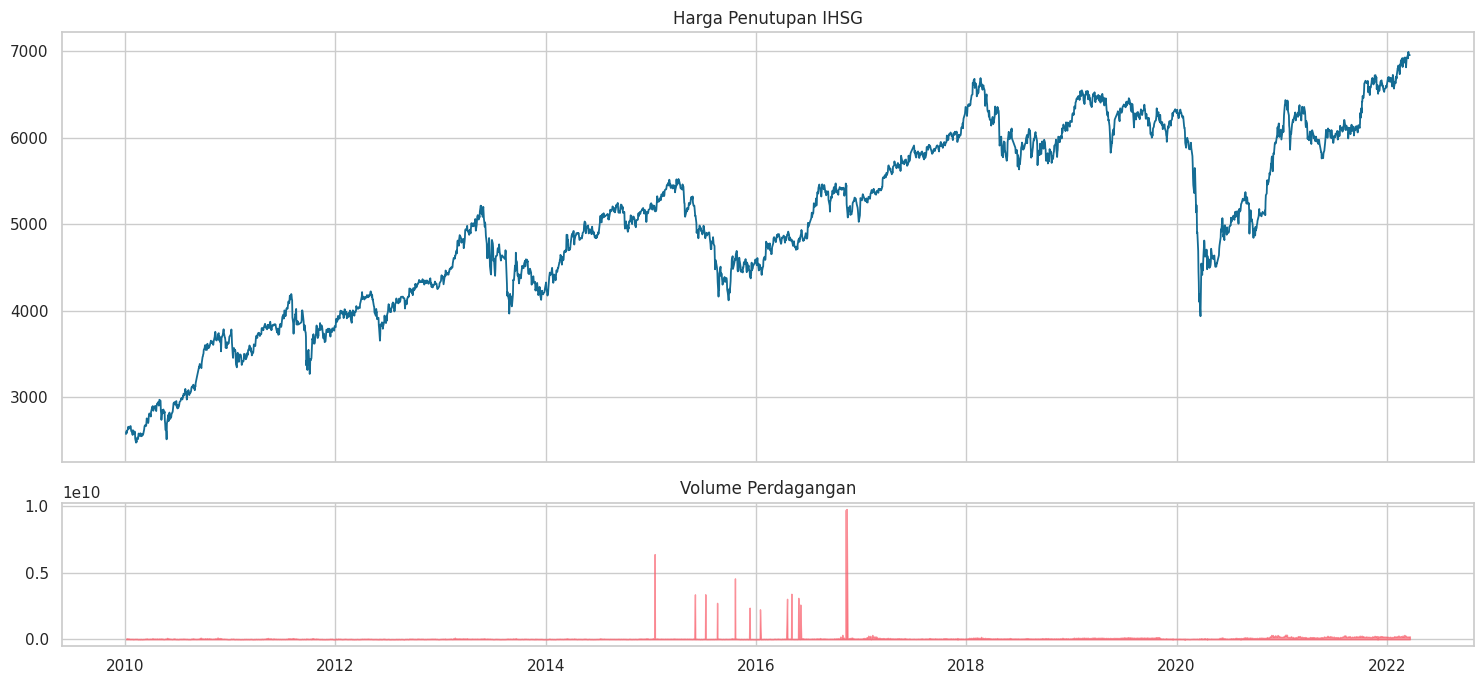

In [12]:
def flatten_cols(df):
    x=df.copy()
    if isinstance(x.columns,pd.MultiIndex): x.columns=[c[0] for c in x.columns]
    return x

def standardize(df):
    x=df.copy()
    x.columns=[str(c).strip().title().replace("_"," ") for c in x.columns]
    x=x.rename(columns={"Tanggal":"Date","Datetime":"Date","Timestamp":"Date"})
    if "Date" in x.columns:
        x["Date"]=pd.to_datetime(x["Date"],errors="coerce"); x=x.set_index("Date")
    x.index=pd.to_datetime(x.index,errors="coerce"); x.index.name="Date"
    req=["Open","High","Low","Close","Volume"]
    miss=[c for c in req if c not in x.columns]
    if miss: raise ValueError(f"Kolom wajib hilang: {miss}")
    x=x[req].apply(pd.to_numeric,errors="coerce")
    x=x[~x.index.isna()].sort_index()
    x=x[~x.index.duplicated(keep="last")]
    return x.dropna(subset=req)

def load_data():
    candidates=sorted(INPUT_ROOT.rglob("*.csv"),
      key=lambda p:(0 if any(k in p.name.lower() for k in ["ihsg","jkse"]) else 1,str(p)))
    for p in candidates:
        try:
            x=standardize(pd.read_csv(p))
            if len(x)>=500: return x,f"CSV relatif: {p}"
        except Exception: continue
    try:
        x=yf.download(CFG["ticker"],start=CFG["start"],end=CFG["end"],
                      auto_adjust=False,progress=False,threads=False)
        x=standardize(flatten_cols(x))
        if len(x)<500: raise ValueError("Data daring terlalu sedikit")
        return x,"Yahoo Finance (^JKSE)"
    except Exception as online_error:
        raise RuntimeError("Aktifkan Internet atau unggah CSV OHLCV IHSG.") from online_error

raw,source=load_data()
raw=raw.loc[(raw.index>=pd.Timestamp(CFG["start"])) & (raw.index<pd.Timestamp(CFG["end"]))].copy()
if len(raw)<500: raise RuntimeError("Data dalam periode terkunci kurang dari 500 baris.")
canonical_csv=raw.reset_index().to_csv(index=False,date_format="%Y-%m-%d",float_format="%.10g")
DATASET_HASH=hashlib.sha256(canonical_csv.encode("utf-8")).hexdigest()
(OUT/"00_ihsg_raw_locked.csv").write_text(canonical_csv,encoding="utf-8")
quality=pd.DataFrame({
 "Pemeriksaan":["Sumber","Awal","Akhir","Baris","SHA-256 dataset","Duplikasi","Kosong","High < Low","Volume negatif"],
 "Hasil":[source,raw.index.min().date(),raw.index.max().date(),len(raw),
          DATASET_HASH,
          raw.index.duplicated().sum(),raw.isna().sum().sum(),
          (raw.High<raw.Low).sum(),(raw.Volume<0).sum()]})
display(raw.head()); display(quality)

fig,ax=plt.subplots(2,1,figsize=(15,7),sharex=True,gridspec_kw={"height_ratios":[3,1]})
ax[0].plot(raw.index,raw.Close,color="#146C94",lw=1.3); ax[0].set_title("Harga Penutupan IHSG")
ax[1].fill_between(raw.index,raw.Volume.to_numpy(),color="#F95D6A",alpha=.65)
ax[1].set_title("Volume Perdagangan"); plt.tight_layout(); plt.show()

# Tahap 5. Fitur dan Target

Fitur memakai informasi pada hari \\(t\\) atau sebelumnya. Satu-satunya
pergeseran ke depan dipakai untuk target dan tanggal target.

,InputEndDate,TargetDate,Close,Target,TargetAfterInput
Date,,,,,
2022-03-09,2022-03-09,2022-03-10,6864.440918,1,True
2022-03-10,2022-03-10,2022-03-11,6924.007813,0,True
2022-03-11,2022-03-11,2022-03-14,6922.602051,1,True
2022-03-14,2022-03-14,2022-03-15,6952.204102,0,True
2022-03-15,2022-03-15,2022-03-16,6918.185059,1,True
2022-03-16,2022-03-16,2022-03-17,6992.395020,0,True
2022-03-17,2022-03-17,2022-03-18,6964.384766,0,True
2022-03-18,2022-03-18,2022-03-21,6954.964844,1,True


,mean,std,min,max
Open,5.035530e+03,1.028166e+03,2474.7500,7.016532e+03
High,5.061835e+03,1.028353e+03,2490.1089,7.032702e+03
Low,5.005275e+03,1.026052e+03,2431.8379,6.949166e+03
Close,5.034853e+03,1.025833e+03,2475.5720,6.992395e+03
Volume,8.792309e+07,3.345433e+08,0.0000,9.788202e+09
Return1,4.000000e-04,1.090000e-02,-0.0888,1.019000e-01
LogReturn,3.000000e-04,1.090000e-02,-0.0930,9.700000e-02
RangePct,1.170000e-02,8.300000e-03,0.0000,1.002000e-01
OCChange,0.000000e+00,9.900000e-03,-0.0884,1.019000e-01
SMA5Ratio,7.000000e-04,1.210000e-02,-0.0873,8.190000e-02


,Jumlah,Proporsi
Target,,
Turun/Tetap,1338,45.31%
Naik,1615,54.69%


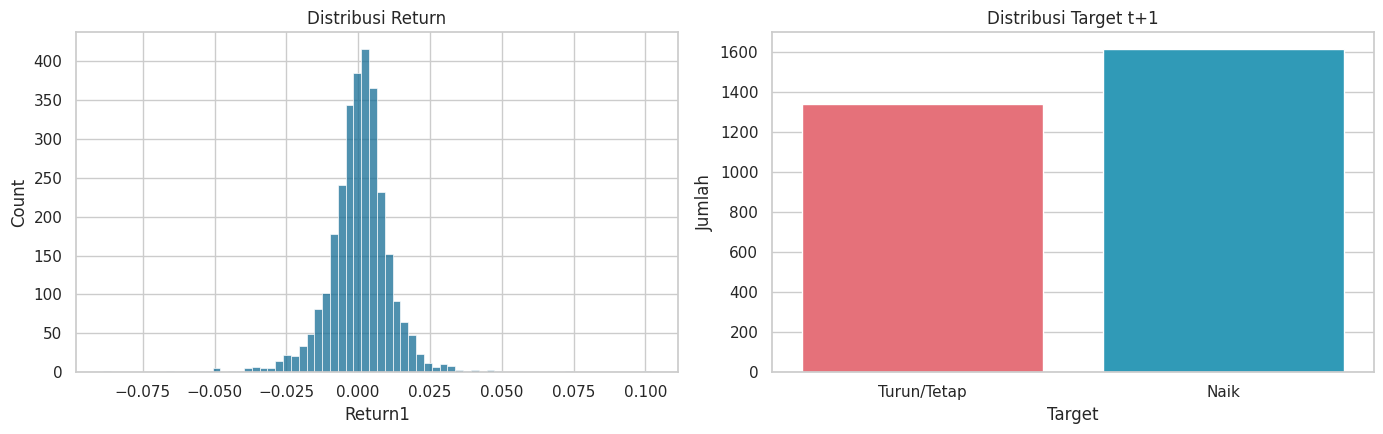

In [13]:
def rsi(s,n=14):
    d=s.diff(); g=d.clip(lower=0).ewm(alpha=1/n,adjust=False).mean()
    l=(-d.clip(upper=0)).ewm(alpha=1/n,adjust=False).mean()
    return 100-100/(1+g/l.replace(0,np.nan))

def feature_engineering(x):
    d=x.copy()
    d["Return1"]=d.Close.pct_change(); d["LogReturn"]=np.log(d.Close).diff()
    d["RangePct"]=(d.High-d.Low)/d.Close; d["OCChange"]=(d.Close-d.Open)/d.Open
    d["SMA5Ratio"]=d.Close/d.Close.rolling(5).mean()-1
    d["SMA20Ratio"]=d.Close/d.Close.rolling(20).mean()-1
    e12=d.Close.ewm(span=12,adjust=False).mean(); e26=d.Close.ewm(span=26,adjust=False).mean()
    d["MACD"]=(e12-e26)/d.Close; d["RSI14"]=rsi(d.Close)/100
    d["Volatility10"]=d.LogReturn.rolling(10).std()
    d["VolumeChange"]=d.Volume.pct_change().replace([np.inf,-np.inf],np.nan)
    d["VolumeZ20"]=(d.Volume-d.Volume.rolling(20).mean())/d.Volume.rolling(20).std().replace(0,np.nan)
    nxt=d.Close.shift(-1); d["Target"]=np.where(nxt.notna(),(nxt>d.Close).astype(int),np.nan)
    d["TargetDate"]=pd.Series(d.index,index=d.index).shift(-1)
    return d

FEATURES=["Open","High","Low","Close","Volume","Return1","LogReturn","RangePct",
          "OCChange","SMA5Ratio","SMA20Ratio","MACD","RSI14","Volatility10",
          "VolumeChange","VolumeZ20"]
data=feature_engineering(raw).replace([np.inf,-np.inf],np.nan)
data=data.dropna(subset=FEATURES+["Target","TargetDate"]).copy()
data["Target"]=data.Target.astype(int)
align=data[["Close","Target","TargetDate"]].tail(8).copy()
align["InputEndDate"]=align.index; align["TargetAfterInput"]=align.TargetDate>align.InputEndDate
display(align[["InputEndDate","TargetDate","Close","Target","TargetAfterInput"]])
display(data[FEATURES].describe().T[["mean","std","min","max"]].round(4))
classes=data.Target.value_counts().sort_index().rename(index={0:"Turun/Tetap",1:"Naik"}).to_frame("Jumlah")
classes["Proporsi"]=classes.Jumlah/classes.Jumlah.sum()
display(classes.style.format({"Proporsi":"{:.2%}"}))
fig,ax=plt.subplots(1,2,figsize=(14,4.5))
sns.histplot(data=data,x="Return1",bins=70,color="#146C94",ax=ax[0]); ax[0].set_title("Distribusi Return")
sns.barplot(x=classes.index,y=classes.Jumlah,palette=["#F95D6A","#19A7CE"],ax=ax[1])
ax[1].set_title("Distribusi Target t+1"); plt.tight_layout(); plt.show()

# Tahap 6. Split, Normalisasi, dan Tensor
Split mengikuti waktu. Scaler hanya di-*fit* pada baris latih.

,Split,Sampel,Awal target,Akhir target,Proporsi naik
0,Train,2038,2010-03-12 00:00:00,2018-07-25 00:00:00,55.54%
1,Validasi,443,2018-07-26 00:00:00,2020-05-20 00:00:00,51.47%
2,Test,443,2020-05-26 00:00:00,2022-03-18 00:00:00,54.18%


,Tensor,Shape,Finite
0,X_train,"(2038, 30, 16)",True
1,X_val,"(443, 30, 16)",True
2,X_test,"(443, 30, 16)",True
3,y_train,"(2038,)",True
4,y_val,"(443,)",True
5,y_test,"(443,)",True


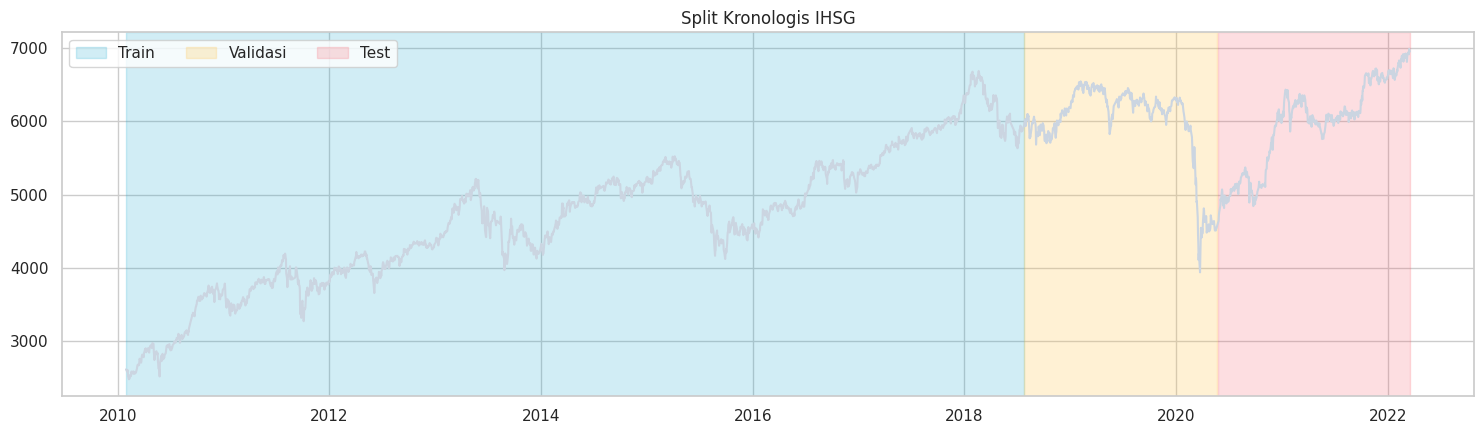

In [14]:
n=len(data); tr=int(n*CFG["train_ratio"]); va=int(n*(CFG["train_ratio"]+CFG["val_ratio"]))
scaler=StandardScaler().fit(data.iloc[:tr][FEATURES])
Xall=scaler.transform(data[FEATURES]).astype("float32"); yall=data.Target.to_numpy("float32")

def sequences(X,y,idx,w,tr,va):
    B={k:{"X":[],"y":[],"d":[]} for k in ["train","val","test"]}
    for e in range(w-1,len(X)):
        k="train" if e<tr else ("val" if e<va else "test")
        B[k]["X"].append(X[e-w+1:e+1]); B[k]["y"].append(y[e]); B[k]["d"].append(idx[e])
    return {k:(np.asarray(v["X"],dtype="float32"),np.asarray(v["y"],dtype="float32"),
               pd.DatetimeIndex(v["d"])) for k,v in B.items()}

S=sequences(Xall,yall,data.index,CFG["window"],tr,va)
X_train,y_train,d_train=S["train"]; X_val,y_val,d_val=S["val"]; X_test,y_test,d_test=S["test"]
split=pd.DataFrame([
 ["Train",len(X_train),d_train.min(),d_train.max(),y_train.mean()],
 ["Validasi",len(X_val),d_val.min(),d_val.max(),y_val.mean()],
 ["Test",len(X_test),d_test.min(),d_test.max(),y_test.mean()]],
 columns=["Split","Sampel","Awal target","Akhir target","Proporsi naik"])
tensor=pd.DataFrame({"Tensor":["X_train","X_val","X_test","y_train","y_val","y_test"],
 "Shape":[str(z.shape) for z in [X_train,X_val,X_test,y_train,y_val,y_test]],
 "Finite":[np.isfinite(z).all() for z in [X_train,X_val,X_test,y_train,y_val,y_test]]})
display(split.style.format({"Proporsi naik":"{:.2%}"})); display(tensor)
fig,ax=plt.subplots(figsize=(15,4.5)); ax.plot(data.index,data.Close,color="#CBD5E1")
ax.axvspan(data.index[0],data.index[tr-1],color="#19A7CE",alpha=.2,label="Train")
ax.axvspan(data.index[tr],data.index[va-1],color="#FFC857",alpha=.25,label="Validasi")
ax.axvspan(data.index[va],data.index[-1],color="#F95D6A",alpha=.2,label="Test")
ax.set_title("Split Kronologis IHSG"); ax.legend(ncol=3); plt.tight_layout(); plt.show()

# Tahap 7. Audit Kebocoran

Audit kritis menghentikan eksperimen jika gagal. BiGRU tidak otomatis bocor:
arah mundur hanya membaca ulang isi jendela historis yang berakhir pada hari \\(t\\).

In [15]:
audit=[]
def check(name,ok,evidence,level="KRITIS"):
    audit.append({"Pemeriksaan":name,"Lulus":bool(ok),"Bukti":str(evidence),"Tingkat":level})
check("Index meningkat",data.index.is_monotonic_increasing,data.index.is_monotonic_increasing)
check("Tanggal unik",data.index.is_unique,f"duplikat={data.index.duplicated().sum()}")
check("Target setelah input",(data.TargetDate>data.index).all(),"semua target > input")
check("Split tidak tumpang tindih",d_train.max()<d_val.min()<d_test.min(),
      f"{d_train.max().date()} < {d_val.min().date()} < {d_test.min().date()}")
check("Scaler train-only",scaler.n_samples_seen_==tr,f"{scaler.n_samples_seen_} = {tr}")
check("Tensor 3D",X_train.ndim==X_val.ndim==X_test.ndim==3,
      f"{X_train.shape}, {X_val.shape}, {X_test.shape}")
check("Window benar",X_train.shape[1]==CFG["window"],X_train.shape[1])
check("Fitur benar",X_train.shape[2]==len(FEATURES),X_train.shape[2])
check("Nilai finite",all(np.isfinite(z).all() for z in [X_train,X_val,X_test]),"tanpa NaN/Inf")
check("Test dua kelas",len(np.unique(y_test))==2,np.unique(y_test).tolist(),"TINGGI")
audit_df=pd.DataFrame(audit)
display(audit_df.style.apply(lambda r:["background-color:#DCFCE7" if r.Lulus else
 "#FEE2E2"]*len(r),axis=1))
if len(audit_df.query("Tingkat=='KRITIS' and Lulus==False")):
    raise RuntimeError("AUDIT GAGAL. Eksperimen dihentikan.")

,Pemeriksaan,Lulus,Bukti,Tingkat
0,Index meningkat,True,True,KRITIS
1,Tanggal unik,True,duplikat=0,KRITIS
2,Target setelah input,True,semua target > input,KRITIS
3,Split tidak tumpang tindih,True,2018-07-25 < 2018-07-26 < 2020-05-26,KRITIS
4,Scaler train-only,True,2067 = 2067,KRITIS
5,Tensor 3D,True,"(2038, 30, 16), (443, 30, 16), (443, 30, 16)",KRITIS
6,Window benar,True,30,KRITIS
7,Fitur benar,True,16,KRITIS
8,Nilai finite,True,tanpa NaN/Inf,KRITIS
9,Test dua kelas,True,"[0.0, 1.0]",TINGGI


# Tahap 8. Arsitektur

Kedua model memakai CNN dan BiGRU identik. Pembanding memakai rata-rata global,
sedangkan model perlakuan memakai *additive temporal attention*.

In [16]:
@tf.keras.utils.register_keras_serializable(package="IHSG")
class TemporalAttention(tf.keras.layers.Layer):
    # Additive temporal attention yang kompatibel dengan Keras 3.
    # `weights` tidak dipakai sebagai nama metode karena merupakan properti Layer.
    def __init__(self,units=32,**kw):
        super().__init__(**kw); self.units=units
        self.energy=tf.keras.layers.Dense(units,activation="tanh",name="energy")
        self.projection=tf.keras.layers.Dense(1,use_bias=False,name="projection")
    def compute_attention_weights(self,inputs):
        logits=self.projection(self.energy(inputs))
        return tf.nn.softmax(logits,axis=1)
    def call(self,inputs):
        alpha=self.compute_attention_weights(inputs)
        return tf.reduce_sum(inputs*alpha,axis=1)
    def get_config(self): return {**super().get_config(),"units":self.units}

def set_seed(seed):
    os.environ["PYTHONHASHSEED"]=str(seed); random.seed(seed); np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

def build_model(shape,attention,seed):
    tf.keras.backend.clear_session(); set_seed(seed)
    i=tf.keras.Input(shape=shape,name="window")
    x=tf.keras.layers.Conv1D(32,2,padding="causal",activation="relu",name="cnn")(i)
    x=tf.keras.layers.BatchNormalization(name="bn")(x)
    x=tf.keras.layers.Dropout(.2,seed=seed)(x)
    x=tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32,return_sequences=True,
           dropout=.1),name="bigru")(x)
    x=tf.keras.layers.Dropout(.2,seed=seed+1)(x)
    if attention:
        x=TemporalAttention(32,name="attention")(x); name="CNN-BiGRU-Attention"
    else:
        x=tf.keras.layers.GlobalAveragePooling1D(name="average")(x); name="CNN-BiGRU"
    x=tf.keras.layers.Dense(32,activation="relu")(x)
    x=tf.keras.layers.Dropout(.15,seed=seed+2)(x)
    o=tf.keras.layers.Dense(1,activation="sigmoid")(x)
    m=tf.keras.Model(i,o,name=name)
    m.compile(tf.keras.optimizers.Adam(CFG["lr"]),"binary_crossentropy",
              metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"),
                       tf.keras.metrics.AUC(name="auc")])
    return m

b=build_model(X_train.shape[1:],False,CFG["seeds"][0])
a=build_model(X_train.shape[1:],True,CFG["seeds"][0])
att_layer=a.get_layer("attention")
encoder=tf.keras.Model(a.input,a.get_layer("bigru").output)
probe=encoder(X_train[:2],training=False)
probe_alpha=att_layer.compute_attention_weights(probe).numpy()
assert isinstance(att_layer.weights,list), "Properti Layer.weights tertimpa."
assert np.allclose(probe_alpha.sum(axis=1),1.0,atol=1e-6), "Bobot Attention tidak berjumlah satu."
display(pd.DataFrame({
 "Model":["CNN-BiGRU","CNN-BiGRU-Attention"],
 "Agregasi":["Rata-rata global","Bobot Attention"],
 "Parameter":[b.count_params(),a.count_params()],
 "Input":[str(X_train.shape[1:])]*2,"Output":[str(b.output_shape),str(a.output_shape)],
 "Keras_Weights_OK":[True,isinstance(att_layer.weights,list)]}))
display(pd.DataFrame({"Pemeriksaan":["Shape bobot Attention","Jumlah bobot per sampel"],
 "Hasil":[str(probe_alpha.shape),np.round(probe_alpha.sum(axis=1),6).tolist()],
 "Status":["LULUS","LULUS"]}))

I0000 00:00:1785576854.368749      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


,Model,Agregasi,Parameter,Input,Output,Keras_Weights_OK
0,CNN-BiGRU,Rata-rata global,15969,"(30, 16)","(None, 1)",True
1,CNN-BiGRU-Attention,Bobot Attention,18081,"(30, 16)","(None, 1)",True


,Pemeriksaan,Hasil,Status
0,Shape bobot Attention,"(2, 30, 1)",LULUS
1,Jumlah bobot per sampel,"[[1.0], [1.0]]",LULUS


# Tahap 9. Pelatihan Lima *Seed*

Pelatihan dilakukan berpasangan. Urutan model diselang-seling untuk mengurangi
bias beban perangkat. *Early stopping* mengembalikan bobot validasi terbaik.

2026-08-01 09:34:18.506203: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-08-01 09:34:24.232680: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

CNN-BiGRU                | seed=11 | val_acc=0.5214 | 9.3s


2026-08-01 09:34:32.709953: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


CNN-BiGRU-Attention      | seed=11 | val_acc=0.5147 | 7.4s


2026-08-01 09:34:38.304041: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-08-01 09:34:46.867967: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

...

CNN-BiGRU                | seed=71 | val_acc=0.5079 | 7.2s


2026-08-01 09:35:48.445901: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


CNN-BiGRU-Attention      | seed=71 | val_acc=0.5237 | 6.5s


,Run_ID,Seed,Model,Duration_s,Dataset_SHA256,Device,Status,Error
0,cnn_bigru_seed_11,11,CNN-BiGRU,9.299984,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...,"[PhysicalDevice(name='/physical_device:GPU:0',...",SUCCESS,
1,cnn_bigru_attention_seed_11,11,CNN-BiGRU-Attention,7.427945,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...,"[PhysicalDevice(name='/physical_device:GPU:0',...",SUCCESS,
2,cnn_bigru_attention_seed_23,23,CNN-BiGRU-Attention,8.502570,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...,"[PhysicalDevice(name='/physical_device:GPU:0',...",SUCCESS,
3,cnn_bigru_seed_23,23,CNN-BiGRU,7.754422,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...,"[PhysicalDevice(name='/physical_device:GPU:0',...",SUCCESS,
4,cnn_bigru_seed_37,37,CNN-BiGRU,7.732841,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...,"[PhysicalDevice(name='/physical_device:GPU:0',...",SUCCESS,
5,cnn_bigru_attention_seed_37,37,CNN-BiGRU-Attention,6.940949,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...,"[PhysicalDevice(name='/physical_device:GPU:0',...",SUCCESS,
6,cnn_bigru_attention_seed_53,53,CNN-BiGRU-Attention,7.493833,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...,"[PhysicalDevice(name='/physical_device:GPU:0',...",SUCCESS,
7,cnn_bigru_seed_53,53,CNN-BiGRU,9.630839,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...,"[PhysicalDevice(name='/physical_device:GPU:0',...",SUCCESS,
8,cnn_bigru_seed_71,71,CNN-BiGRU,7.237352,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...,"[PhysicalDevice(name='/physical_device:GPU:0',...",SUCCESS,
9,cnn_bigru_attention_seed_71,71,CNN-BiGRU-Attention,6.475388,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...,"[PhysicalDevice(name='/physical_device:GPU:0',...",SUCCESS,


,Model,Seed,Train_Time_s,Parameters,Epochs_Run,Best_Epoch,Best_Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_ROC_AUC
0,CNN-BiGRU,11,9.3,15969,8,3,0.6925,0.5214,0.5312,0.5965,0.5620,0.5218
1,CNN-BiGRU-Attention,11,7.4,18081,8,3,0.6961,0.5147,0.5147,1.0000,0.6796,0.5348
2,CNN-BiGRU,23,7.8,15969,10,5,0.6986,0.5147,0.5147,1.0000,0.6796,0.4958
3,CNN-BiGRU-Attention,23,8.5,18081,10,5,0.6951,0.5124,0.5182,0.7500,0.6129,0.5095
4,CNN-BiGRU,37,7.7,15969,10,5,0.6993,0.5147,0.5147,1.0000,0.6796,0.5043
5,CNN-BiGRU-Attention,37,6.9,18081,7,2,0.6925,0.4989,0.5133,0.5088,0.5110,0.5187
6,CNN-BiGRU,53,9.6,15969,14,9,0.6952,0.4853,0.5000,0.1711,0.2549,0.5300
7,CNN-BiGRU-Attention,53,7.5,18081,8,3,0.7038,0.4831,0.4889,0.0965,0.1612,0.5086
8,CNN-BiGRU,71,7.2,15969,9,4,0.6947,0.5079,0.5368,0.3202,0.4011,0.5260
9,CNN-BiGRU-Attention,71,6.5,18081,6,1,0.6954,0.5237,0.5556,0.3728,0.4462,0.5105


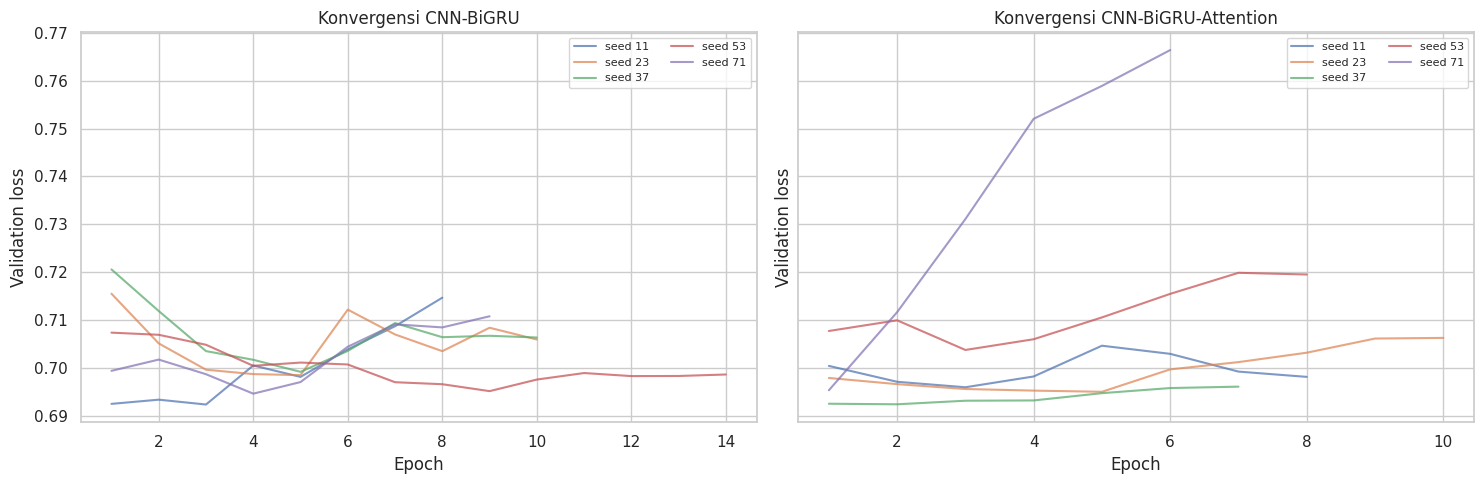

In [17]:
def auc(y,p): return roc_auc_score(y,p) if len(np.unique(y))==2 else np.nan
def get_attention(m,X):
    enc=tf.keras.Model(m.input,m.get_layer("bigru").output)
    h=enc.predict(X,verbose=0); layer=m.get_layer("attention")
    alpha=layer.compute_attention_weights(tf.convert_to_tensor(h))
    return tf.squeeze(alpha,-1).numpy()

def classification_metrics(y,prob,prefix):
    pred=(prob>=CFG["threshold"]).astype(int)
    return {f"{prefix}_Accuracy":accuracy_score(y,pred),
            f"{prefix}_Precision":precision_score(y,pred,zero_division=0),
            f"{prefix}_Recall":recall_score(y,pred,zero_division=0),
            f"{prefix}_F1":f1_score(y,pred,zero_division=0),
            f"{prefix}_ROC_AUC":auc(y,prob)}

rows=[]; experiment_logs=[]; histories={}; trained_weights={"CNN-BiGRU":{},"CNN-BiGRU-Attention":{}}
val_predictions={"CNN-BiGRU":{},"CNN-BiGRU-Attention":{}}
attention_maps={}
for si,seed in enumerate(CFG["seeds"]):
    for use_att in ([False,True] if si%2==0 else [True,False]):
        label="CNN-BiGRU-Attention" if use_att else "CNN-BiGRU"
        run_id=f"{label.lower().replace('-','_')}_seed_{seed}"
        started=datetime.now(timezone.utc); checkpoint=CHECKPOINT_DIR/f"{run_id}.weights.h5"
        gc.collect(); m=build_model(X_train.shape[1:],use_att,seed)
        cb=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=CFG["patience"],
              restore_best_weights=True,min_delta=1e-4),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=.5,
              patience=2,min_lr=1e-5),
            tf.keras.callbacks.ModelCheckpoint(checkpoint,monitor="val_loss",
              save_best_only=True,save_weights_only=True)]
        t=time.perf_counter(); status="FAILED"; error_message=""
        try:
            h=m.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=CFG["epochs"],
                    batch_size=CFG["batch_size"],shuffle=False,callbacks=cb,verbose=0)
            elapsed=time.perf_counter()-t
            m.load_weights(checkpoint)
            val_prob=m.predict(X_val,verbose=0).ravel()
            val_predictions[label][seed]=val_prob
            trained_weights[label][seed]=[w.copy() for w in m.get_weights()]
            histories[(label,seed)]=h.history
            if use_att: attention_maps[seed]=get_attention(m,X_val[-min(200,len(X_val)):])
            row={"Model":label,"Seed":seed,"Train_Time_s":elapsed,
                 "Parameters":m.count_params(),"Epochs_Run":len(h.history["loss"]),
                 "Best_Epoch":int(np.argmin(h.history["val_loss"])+1),
                 "Best_Val_Loss":min(h.history["val_loss"])}
            row.update(classification_metrics(y_val,val_prob,"Val")); rows.append(row)
            status="SUCCESS"
            print(f"{label:24s} | seed={seed} | val_acc={row['Val_Accuracy']:.4f} | {elapsed:.1f}s")
        except Exception as exc:
            elapsed=time.perf_counter()-t; error_message=repr(exc)
            print(f"GAGAL | {label} | seed={seed} | {error_message}")
        finished=datetime.now(timezone.utc)
        experiment_logs.append({
          "Run_ID":run_id,"Started_UTC":started.isoformat(),"Finished_UTC":finished.isoformat(),
          "Duration_s":elapsed,"Seed":seed,"Model":label,"Dataset_SHA256":DATASET_HASH,
          "Python":RUNTIME["python"],"TensorFlow":RUNTIME["tensorflow"],
          "NumPy":RUNTIME["numpy"],"Pandas":RUNTIME["pandas"],"Device":RUNTIME["device"],
          "Parameters":m.count_params(),"Window":CFG["window"],"Epoch_Limit":CFG["epochs"],
          "Batch_Size":CFG["batch_size"],"Learning_Rate":CFG["lr"],
          "Checkpoint":str(checkpoint),"Status":status,"Error":error_message})

results=pd.DataFrame(rows).sort_values(["Seed","Model"]).reset_index(drop=True)
experiment_log=pd.DataFrame(experiment_logs)
display(experiment_log[["Run_ID","Seed","Model","Duration_s","Dataset_SHA256","Device","Status","Error"]])
if len(results)!=2*len(CFG["seeds"]):
    experiment_log.to_csv(OUT/"experiment_log_partial.csv",index=False)
    raise RuntimeError("Tidak semua eksperimen berhasil. Periksa log parsial.")
experiment_log=experiment_log.merge(results,on=["Seed","Model"],how="left",suffixes=("","_result"))
metric_cols=[c for c in results if c.startswith("Val_")]
fmt={c:"{:.4f}" for c in metric_cols}
fmt.update({"Train_Time_s":"{:.1f}","Best_Val_Loss":"{:.4f}"})
display(results.style.format(fmt))

fig,ax=plt.subplots(1,2,figsize=(15,5),sharey=True)
for z,label,col in zip(ax,["CNN-BiGRU","CNN-BiGRU-Attention"],["#146C94","#D45087"]):
    for seed in CFG["seeds"]:
        curve=histories[(label,seed)]["val_loss"]
        z.plot(range(1,len(curve)+1),curve,alpha=.72,lw=1.5,label=f"seed {seed}")
    z.set(title=f"Konvergensi {label}",xlabel="Epoch",ylabel="Validation loss")
    z.legend(ncol=2,fontsize=8)
plt.tight_layout(); plt.show()

# Tahap 10. Stabilitas dan Interpretabilitas

Rubrik interpretabilitas 0 sampai 5 memadukan kesederhanaan (2), keterlacakan
waktu (1), dan reprodusibilitas prediksi antarseed (2). Rubrik ini transparan,
tetapi bukan bukti kausalitas atau standar industri.

,Model,Seed,Val_Accuracy,Val_Accuracy_Deviation,Train_Time_s,Interpretability_0_5
0,CNN-BiGRU,11,0.5214,+0.0126,9.3,2.88
1,CNN-BiGRU-Attention,11,0.5147,+0.0081,7.4,2.25
2,CNN-BiGRU,23,0.5147,+0.0059,7.8,2.88
3,CNN-BiGRU-Attention,23,0.5124,+0.0059,8.5,2.25
4,CNN-BiGRU,37,0.5147,+0.0059,7.7,2.88
5,CNN-BiGRU-Attention,37,0.4989,-0.0077,6.9,2.25
6,CNN-BiGRU,53,0.4853,-0.0235,9.6,2.88
7,CNN-BiGRU-Attention,53,0.4831,-0.0235,7.5,2.25
8,CNN-BiGRU,71,0.5079,-0.0009,7.2,2.88
9,CNN-BiGRU-Attention,71,0.5237,+0.0172,6.5,2.25


,Model,Val_Accuracy_Mean,Val_Accuracy_SD,Val_Accuracy_Min,Val_Accuracy_Max,Val_F1_Mean,Val_F1_SD,Val_AUC_Mean,Train_Time_Mean_s,Train_Time_SD_s,Parameters,Prediction_Stability,Interpretability_0_5
0,CNN-BiGRU,0.5088,0.0140,0.4853,0.5214,0.5154,0.1851,0.5156,8.3311,1.0624,15969,0.3148,2.8796
1,CNN-BiGRU-Attention,0.5065,0.0158,0.4831,0.5237,0.4822,0.2008,0.5164,7.3681,0.7559,18081,0.1265,2.2530


,Model,Simplicity_0_2,Temporal_Trace_0_1,Reproducibility_0_2,Total_0_5
0,CNN-BiGRU,2.0,0.25,0.630,2.880
1,CNN-BiGRU-Attention,1.0,1.00,0.253,2.253


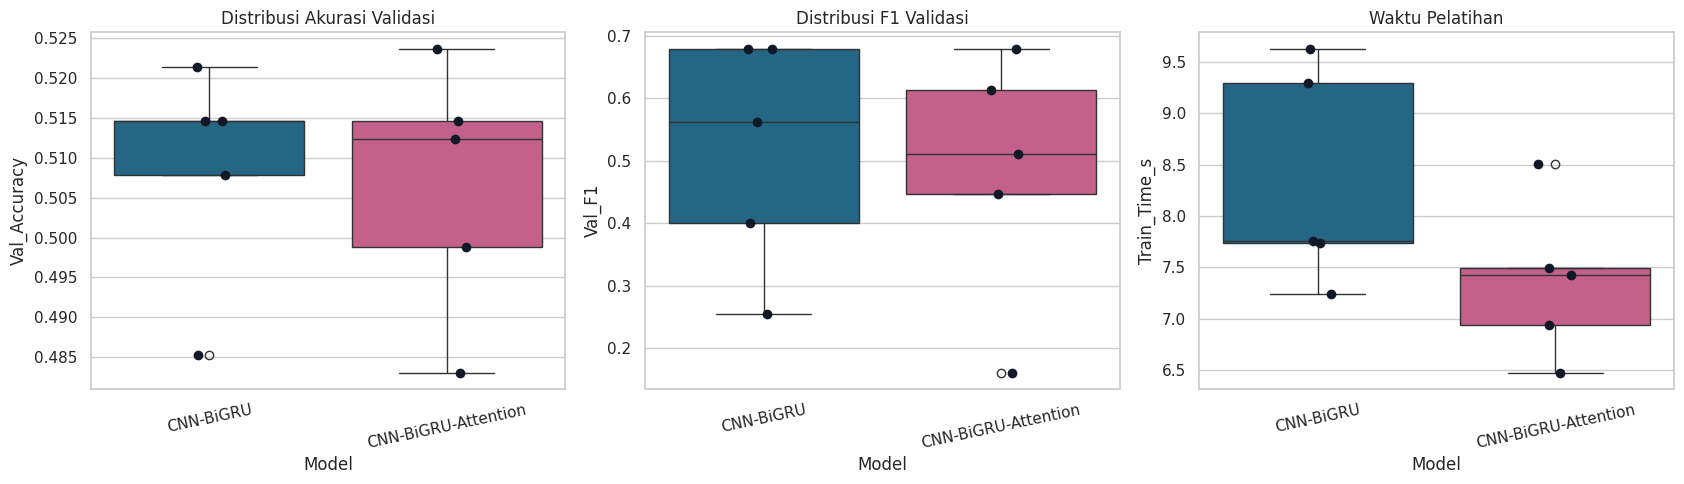

In [18]:
def stability(d):
    s=sorted(d); vals=[]
    for i in range(len(s)):
        for j in range(i+1,len(s)):
            q=spearmanr(d[s[i]],d[s[j]]).statistic
            if np.isfinite(q): vals.append(q)
    return float(np.mean(vals))

stab={k:stability(v) for k,v in val_predictions.items()}
rubric={"CNN-BiGRU":{"Simplicity_0_2":2.0,"Temporal_Trace_0_1":.25,
                     "Reproducibility_0_2":2*max(0,stab["CNN-BiGRU"])},
        "CNN-BiGRU-Attention":{"Simplicity_0_2":1.0,"Temporal_Trace_0_1":1.0,
                     "Reproducibility_0_2":2*max(0,stab["CNN-BiGRU-Attention"])}}
interp={k:float(np.clip(sum(v.values()),0,5)) for k,v in rubric.items()}
results["Prediction_Stability"]=results.Model.map(stab)
results["Interpretability_0_5"]=results.Model.map(interp)
results["Val_Accuracy_Deviation"]=results.Val_Accuracy-results.groupby("Model").Val_Accuracy.transform("mean")
summary=results.groupby("Model").agg(
 Val_Accuracy_Mean=("Val_Accuracy","mean"),Val_Accuracy_SD=("Val_Accuracy","std"),
 Val_Accuracy_Min=("Val_Accuracy","min"),Val_Accuracy_Max=("Val_Accuracy","max"),
 Val_F1_Mean=("Val_F1","mean"),Val_F1_SD=("Val_F1","std"),
 Val_AUC_Mean=("Val_ROC_AUC","mean"),
 Train_Time_Mean_s=("Train_Time_s","mean"),Train_Time_SD_s=("Train_Time_s","std"),
 Parameters=("Parameters","first"),Prediction_Stability=("Prediction_Stability","first"),
 Interpretability_0_5=("Interpretability_0_5","first")).reset_index()
rubric_df=pd.DataFrame(rubric).T.reset_index(names="Model")
rubric_df["Total_0_5"]=rubric_df.Model.map(interp)
display(results[["Model","Seed","Val_Accuracy","Val_Accuracy_Deviation","Train_Time_s",
 "Interpretability_0_5"]].style.format({"Val_Accuracy":"{:.4f}",
 "Val_Accuracy_Deviation":"{:+.4f}","Train_Time_s":"{:.1f}",
 "Interpretability_0_5":"{:.2f}"}))
display(summary.style.format({c:"{:.4f}" for c in summary if c not in ["Model","Parameters"]}))
display(rubric_df.round(3))

fig,ax=plt.subplots(1,3,figsize=(17,5))
pal={"CNN-BiGRU":"#146C94","CNN-BiGRU-Attention":"#D45087"}
for z,metric,title in zip(ax,["Val_Accuracy","Val_F1","Train_Time_s"],
 ["Distribusi Akurasi Validasi","Distribusi F1 Validasi","Waktu Pelatihan"]):
    sns.boxplot(data=results,x="Model",y=metric,hue="Model",palette=pal,legend=False,ax=z)
    sns.stripplot(data=results,x="Model",y=metric,color="#111827",size=7,jitter=.08,ax=z)
    z.set_title(title); z.tick_params(axis="x",rotation=12)
plt.tight_layout(); plt.show()

# Tahap 11. Analisis Berpasangan dan *Attention*

Selisih memakai *seed* yang sama. Wilcoxon hanya menjadi informasi tambahan
karena lima pasangan memiliki daya statistik rendah. Bobot tinggi menunjukkan
fokus komputasional, bukan penyebab ekonomi.

,Seed,Val_Accuracy_Baseline,Val_Accuracy_Attention,Delta_Val_Accuracy,Val_F1_Baseline,Val_F1_Attention,Delta_Val_F1,Val_ROC_AUC_Baseline,Val_ROC_AUC_Attention,Delta_Val_ROC_AUC,Train_Time_s_Baseline,Train_Time_s_Attention,Delta_Train_Time_s,Attention_Wins
0,11,0.5214,0.5147,-0.0068,0.5620,0.6796,0.1176,0.5218,0.5348,0.0130,9.3000,7.4279,-1.8720,0.0000
1,23,0.5147,0.5124,-0.0023,0.6796,0.6129,-0.0667,0.4958,0.5095,0.0137,7.7544,8.5026,0.7481,0.0000
2,37,0.5147,0.4989,-0.0158,0.6796,0.5110,-0.1686,0.5043,0.5187,0.0144,7.7328,6.9409,-0.7919,0.0000
3,53,0.4853,0.4831,-0.0023,0.2549,0.1612,-0.0937,0.5300,0.5086,-0.0214,9.6308,7.4938,-2.1370,0.0000
4,71,0.5079,0.5237,0.0158,0.4011,0.4462,0.0451,0.5260,0.5105,-0.0154,7.2374,6.4754,-0.7620,1.0000


,Statistik,Nilai
0,Mean delta akurasi,-0.002257
1,Median delta,-0.002257
2,Attention menang,1.000000
3,Wilcoxon statistic,4.500000
4,Wilcoxon p-value,0.500000


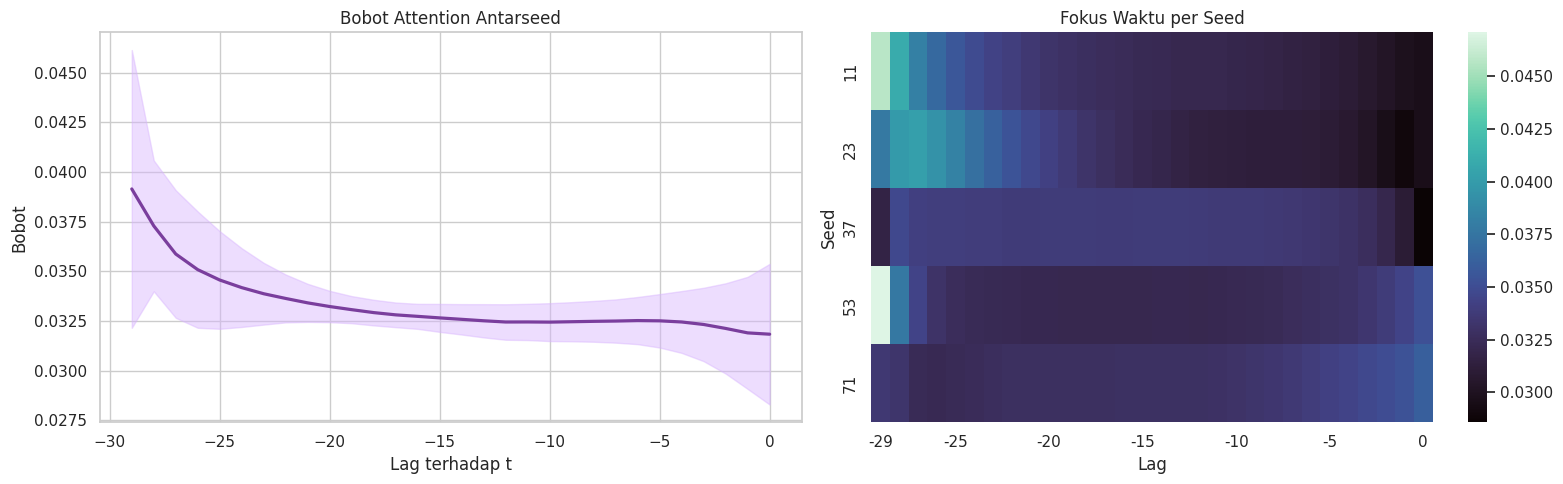

In [19]:
piv=results.pivot(index="Seed",columns="Model",values=["Val_Accuracy","Val_F1","Val_ROC_AUC","Train_Time_s"])
paired=pd.DataFrame(index=CFG["seeds"])
for mtr in ["Val_Accuracy","Val_F1","Val_ROC_AUC","Train_Time_s"]:
    paired[f"{mtr}_Baseline"]=piv[(mtr,"CNN-BiGRU")]
    paired[f"{mtr}_Attention"]=piv[(mtr,"CNN-BiGRU-Attention")]
    paired[f"Delta_{mtr}"]=paired[f"{mtr}_Attention"]-paired[f"{mtr}_Baseline"]
paired.index.name="Seed"; paired=paired.reset_index()
paired["Attention_Wins"]=paired.Delta_Val_Accuracy>0
try: W,P=wilcoxon(paired.Delta_Val_Accuracy)
except Exception: W,P=np.nan,np.nan
display(paired.style.format({c:"{:.4f}" for c in paired if c!="Seed"}))
display(pd.DataFrame({"Statistik":["Mean delta akurasi","Median delta","Attention menang",
 "Wilcoxon statistic","Wilcoxon p-value"],
 "Nilai":[paired.Delta_Val_Accuracy.mean(),paired.Delta_Val_Accuracy.median(),
          paired.Attention_Wins.sum(),W,P]}))

stack=np.stack([attention_maps[s] for s in sorted(attention_maps)])
by_seed=stack.mean(axis=1); mean_att=by_seed.mean(axis=0); sd_att=by_seed.std(axis=0,ddof=1)
lags=np.arange(-CFG["window"]+1,1)
attention_summary=pd.DataFrame({"Lag":lags,"Attention_Mean":mean_att,"Attention_SD":sd_att})
fig,ax=plt.subplots(1,2,figsize=(16,5))
ax[0].plot(lags,mean_att,color="#7A3E9D",lw=2.3)
ax[0].fill_between(lags,mean_att-sd_att,mean_att+sd_att,color="#D8B4FE",alpha=.45)
ax[0].set(title="Bobot Attention Antarseed",xlabel="Lag terhadap t",ylabel="Bobot")
sns.heatmap(by_seed,cmap="mako",ax=ax[1],yticklabels=sorted(attention_maps),
 xticklabels=[str(x) if x%5==0 or x==-29 else "" for x in lags])
ax[1].set(title="Fokus Waktu per Seed",xlabel="Lag",ylabel="Seed")
plt.tight_layout(); plt.show()

# Tahap 12. Keputusan Arsitektur

Seluruh kriteria harus lulus. Aturan konservatif mencegah satu hasil ekstrem
mengalahkan bukti stabilitas, biaya, dan interpretabilitas.

In [20]:
S=summary.set_index("Model"); base=S.loc["CNN-BiGRU"]; att=S.loc["CNN-BiGRU-Attention"]
gain=att.Val_Accuracy_Mean-base.Val_Accuracy_Mean; wins=int(paired.Attention_Wins.sum())
sd_ratio=att.Val_Accuracy_SD/base.Val_Accuracy_SD if base.Val_Accuracy_SD>0 else (
 1.0 if att.Val_Accuracy_SD==0 else np.inf)
time_ratio=att.Train_Time_Mean_s/base.Train_Time_Mean_s
rules=pd.DataFrame([
 ["Kenaikan mean akurasi",gain,f">= {CFG['min_gain']:.3f}",gain>=CFG["min_gain"]],
 ["Kemenangan seed",wins,f">= {CFG['min_wins']}",wins>=CFG["min_wins"]],
 ["Rasio SD akurasi",sd_ratio,f"<= {CFG['max_sd_ratio']:.2f}",sd_ratio<=CFG["max_sd_ratio"]],
 ["Rasio waktu",time_ratio,f"<= {CFG['max_time_ratio']:.2f}",time_ratio<=CFG["max_time_ratio"]],
 ["Interpretabilitas",att.Interpretability_0_5,f">= {base.Interpretability_0_5:.2f}",
  att.Interpretability_0_5>=base.Interpretability_0_5]],
 columns=["Kriteria","Nilai","Ambang","Lulus"])
keep=bool(rules.Lulus.all())
decision="PERTAHANKAN ATTENTION" if keep else "HAPUS ATTENTION DARI ARSITEKTUR AKHIR"
display(rules.style.apply(lambda r:["background-color:#DCFCE7" if r.Lulus else
 "#FEE2E2"]*len(r),axis=1))
failed=", ".join(rules.loc[~rules.Lulus,"Kriteria"]) or "tidak ada"
memo=f'''
## Memorandum Keputusan

**Keputusan: {decision}.**

Pada validasi, CNN-BiGRU menghasilkan akurasi **{base.Val_Accuracy_Mean:.4f} ±
{base.Val_Accuracy_SD:.4f}**. CNN-BiGRU-*Attention* menghasilkan **{att.Val_Accuracy_Mean:.4f}
± {att.Val_Accuracy_SD:.4f}**. Selisih rata-rata ialah **{gain:+.4f}**. *Attention*
menang pada **{wins}/5 seed**. Rasio simpangan baku mencapai **{sd_ratio:.2f}**,
sedangkan rasio waktu pelatihan mencapai **{time_ratio:.2f}**. Skor
interpretabilitas pembanding ialah **{base.Interpretability_0_5:.2f}/5** dan
model *Attention* **{att.Interpretability_0_5:.2f}/5**.

Kriteria yang belum terpenuhi: {failed}. Keputusan tidak memakai akurasi
tertinggi dari satu putaran. Eksperimen lanjutan dapat menguji regularisasi,
unit atensi yang lebih kecil, panjang jendela, *learning rate*, dan jumlah
*seed* lebih besar tanpa mengubah periode uji atau aturan audit.
'''
display(Markdown(memo))

ValueError: Styles supplied as string must follow CSS rule formats, for example 'attr: val;'. '#FEE2E2' was given.


## Memorandum Keputusan

**Keputusan: HAPUS ATTENTION DARI ARSITEKTUR AKHIR.**

Pada validasi, CNN-BiGRU menghasilkan akurasi **0.5088 ±
0.0140**. CNN-BiGRU-*Attention* menghasilkan **0.5065
± 0.0158**. Selisih rata-rata ialah **-0.0023**. *Attention*
menang pada **1/5 seed**. Rasio simpangan baku mencapai **1.13**,
sedangkan rasio waktu pelatihan mencapai **0.88**. Skor
interpretabilitas pembanding ialah **2.88/5** dan
model *Attention* **2.25/5**.

Kriteria yang belum terpenuhi: Kenaikan mean akurasi, Kemenangan seed, Interpretabilitas. Keputusan tidak memakai akurasi
tertinggi dari satu putaran. Eksperimen lanjutan dapat menguji regularisasi,
unit atensi yang lebih kecil, panjang jendela, *learning rate*, dan jumlah
*seed* lebih besar tanpa mengubah periode uji atau aturan audit.


# Tahap 13. Konfirmasi pada Data Uji
Metrik uji dihitung setelah arsitektur dipilih dari validasi. Probabilitas lima
*seed* dirata-ratakan untuk memperoleh estimasi akhir yang lebih stabil.

2026-08-01 09:35:54.327683: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Model,Seed,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,CNN-BiGRU,11,0.4786,0.5155,0.6250,0.5650,0.4804
1,CNN-BiGRU,23,0.5011,0.5263,0.7917,0.6323,0.4907
2,CNN-BiGRU,37,0.5102,0.5281,0.9000,0.6656,0.4883
3,CNN-BiGRU,53,0.5169,0.5793,0.3958,0.4703,0.5154
4,CNN-BiGRU,71,0.5011,0.5543,0.4042,0.4675,0.5051


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,CNN-BiGRU,0.5214,0.5414,0.7625,0.6332,0.5060


,Prediksi Turun/Tetap,Prediksi Naik
Aktual Turun/Tetap,48,155
Aktual Naik,57,183


,precision,recall,f1-score,support
Turun/Tetap,0.4571,0.2365,0.3117,203.0000
Naik,0.5414,0.7625,0.6332,240.0000
accuracy,0.5214,0.5214,0.5214,0.5214
macro avg,0.4993,0.4995,0.4725,443.0000
weighted avg,0.5028,0.5214,0.4859,443.0000


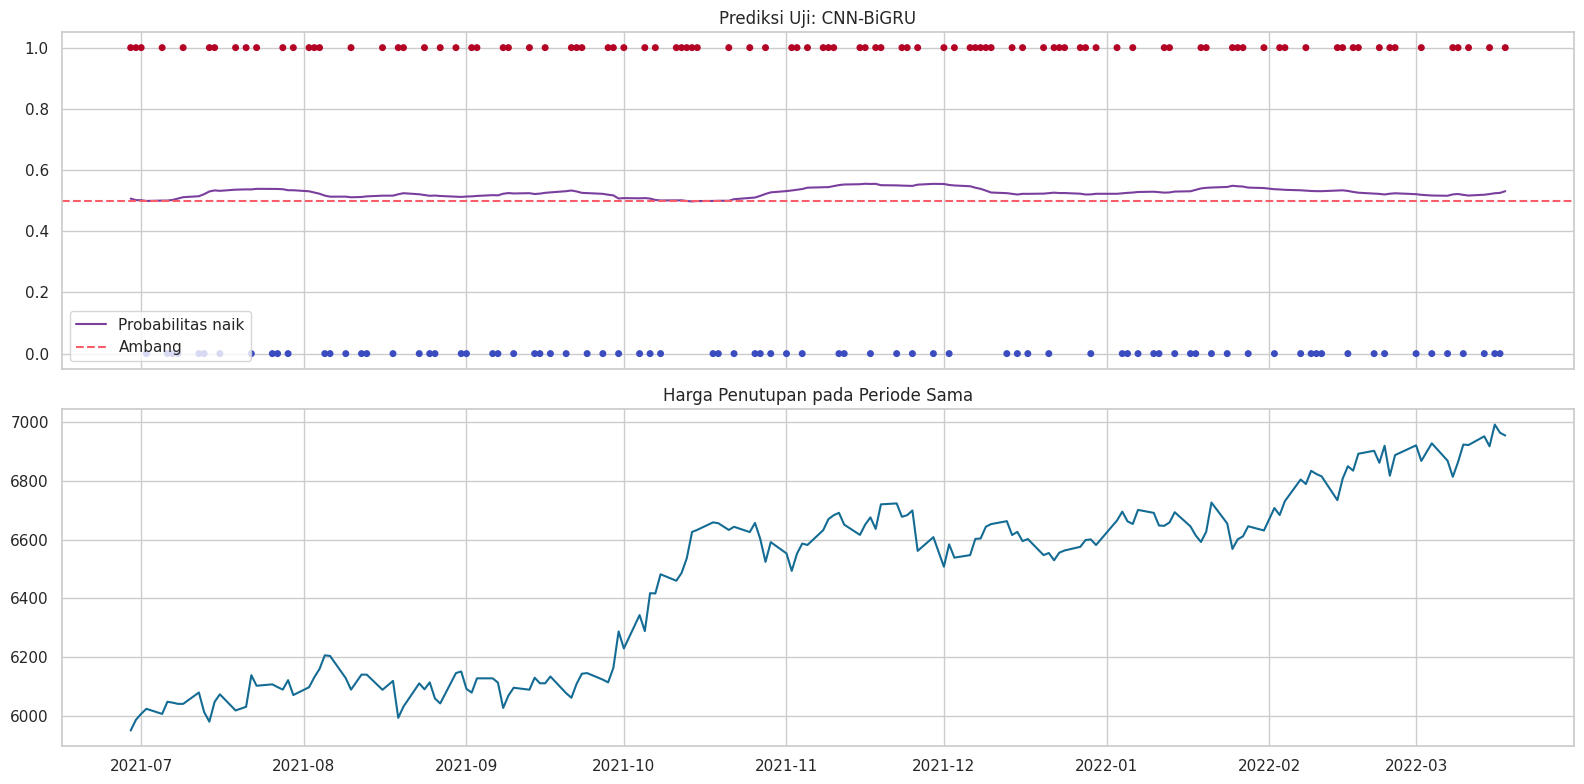

In [21]:
selected="CNN-BiGRU-Attention" if keep else "CNN-BiGRU"
selected_uses_attention=selected=="CNN-BiGRU-Attention"
test_predictions={}; test_seed_rows=[]
for seed in CFG["seeds"]:
    confirm=build_model(X_train.shape[1:],selected_uses_attention,seed)
    confirm.set_weights(trained_weights[selected][seed])
    seed_prob=confirm.predict(X_test,verbose=0).ravel()
    test_predictions[seed]=seed_prob
    seed_row={"Model":selected,"Seed":seed}
    seed_row.update(classification_metrics(y_test,seed_prob,"Test"))
    test_seed_rows.append(seed_row)
test_by_seed=pd.DataFrame(test_seed_rows)
display(test_by_seed.style.format({c:"{:.4f}" for c in test_by_seed if c.startswith("Test_")}))
prob=np.mean(np.stack([test_predictions[s] for s in CFG["seeds"]]),axis=0)
pred=(prob>=CFG["threshold"]).astype(int)
cm=confusion_matrix(y_test.astype(int),pred)
final_test=pd.DataFrame({"Model":[selected],"Accuracy":[accuracy_score(y_test,pred)],
 "Precision":[precision_score(y_test,pred,zero_division=0)],
 "Recall":[recall_score(y_test,pred,zero_division=0)],
 "F1":[f1_score(y_test,pred,zero_division=0)],"ROC_AUC":[auc(y_test,prob)]})
display(final_test.style.format({c:"{:.4f}" for c in final_test if c!="Model"}))
display(pd.DataFrame(cm,index=["Aktual Turun/Tetap","Aktual Naik"],
 columns=["Prediksi Turun/Tetap","Prediksi Naik"]))
display(pd.DataFrame(classification_report(y_test.astype(int),pred,
 target_names=["Turun/Tetap","Naik"],output_dict=True,zero_division=0)).T.round(4))
nplot=min(180,len(y_test)); fig,ax=plt.subplots(2,1,figsize=(16,8),sharex=True)
ax[0].plot(d_test[-nplot:],prob[-nplot:],color="#7A3E9D",label="Probabilitas naik")
ax[0].axhline(.5,color="#F95D6A",ls="--",label="Ambang")
ax[0].scatter(d_test[-nplot:],y_test[-nplot:],c=y_test[-nplot:],cmap="coolwarm",s=16)
ax[0].set_title(f"Prediksi Uji: {selected}"); ax[0].legend()
ax[1].plot(d_test[-nplot:],data.loc[d_test[-nplot:],"Close"],color="#146C94")
ax[1].set_title("Harga Penutupan pada Periode Sama"); plt.tight_layout(); plt.show()

# Tahap 14. Uji Ulang Seed Sama

Eksperimen terpilih pada *seed* pertama dilatih ulang dari nol. Bukti identik
berarti hash prediksi sama untuk data, parameter, *seed*, dan lingkungan yang
sama. Jika hanya lolos toleransi numerik, hasil dicatat sebagai konsisten tetapi
tidak identik. Perbedaan ini tidak disembunyikan.

2026-08-01 09:35:59.918280: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-08-01 09:36:06.608630: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

,Pemeriksaan,Nilai
0,Seed,11
1,Model,CNN-BiGRU
2,Hash dataset,4000056ab42d720dc5f4df5b6216e4591dea6f592d75a8...
3,Hash prediksi awal,cadb4e9ff665833bd456d056b0fa7feded61ff3a07cb78...
4,Hash prediksi rerun,cadb4e9ff665833bd456d056b0fa7feded61ff3a07cb78...
5,Identik byte,True
6,Lolos toleransi,True
7,Selisih absolut maksimum,0.0
8,Status,IDENTIK


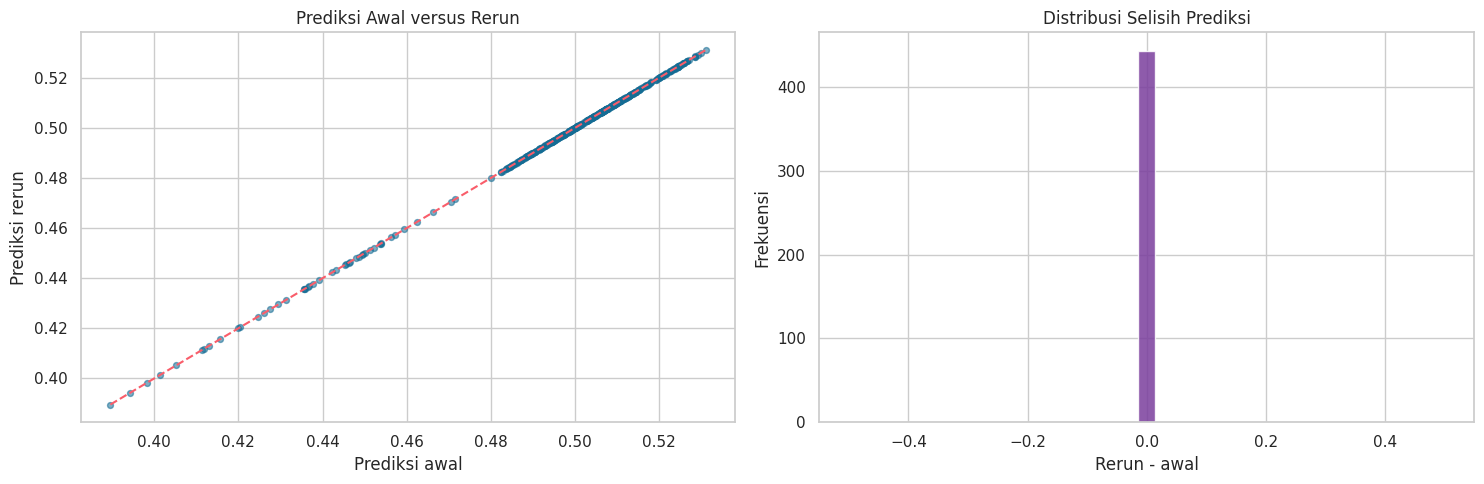

In [22]:
replay_seed=CFG["seeds"][0]
replay_model=build_model(X_train.shape[1:],selected_uses_attention,replay_seed)
replay_checkpoint=CHECKPOINT_DIR/f"replay_{selected.lower().replace('-','_')}_seed_{replay_seed}.weights.h5"
replay_cb=[
 tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=CFG["patience"],
   restore_best_weights=True,min_delta=1e-4),
 tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=.5,patience=2,min_lr=1e-5),
 tf.keras.callbacks.ModelCheckpoint(replay_checkpoint,monitor="val_loss",save_best_only=True,
   save_weights_only=True)]
replay_start=datetime.now(timezone.utc); replay_t=time.perf_counter()
replay_history=replay_model.fit(X_train,y_train,validation_data=(X_val,y_val),
 epochs=CFG["epochs"],batch_size=CFG["batch_size"],shuffle=False,
 callbacks=replay_cb,verbose=0)
replay_duration=time.perf_counter()-replay_t
replay_model.load_weights(replay_checkpoint)
replay_prob=replay_model.predict(X_val,verbose=0).ravel()
original_prob=val_predictions[selected][replay_seed]
original_hash=hashlib.sha256(original_prob.tobytes()).hexdigest()
replay_hash=hashlib.sha256(replay_prob.tobytes()).hexdigest()
exact=bool(np.array_equal(original_prob,replay_prob))
close=bool(np.allclose(original_prob,replay_prob,rtol=1e-6,atol=1e-7))
max_abs=float(np.max(np.abs(original_prob-replay_prob)))
replay_status="IDENTIK" if exact else ("KONSISTEN_DALAM_TOLERANSI" if close else "BERBEDA")
replay_evidence=pd.DataFrame({
 "Pemeriksaan":["Seed","Model","Hash dataset","Hash prediksi awal","Hash prediksi rerun",
                 "Identik byte","Lolos toleransi","Selisih absolut maksimum","Status"],
 "Nilai":[replay_seed,selected,DATASET_HASH,original_hash,replay_hash,exact,close,max_abs,replay_status]})
display(replay_evidence)
fig,ax=plt.subplots(1,2,figsize=(15,5))
ax[0].scatter(original_prob,replay_prob,s=18,alpha=.55,color="#146C94")
lo=min(original_prob.min(),replay_prob.min()); hi=max(original_prob.max(),replay_prob.max())
ax[0].plot([lo,hi],[lo,hi],"--",color="#F95D6A"); ax[0].set(
 title="Prediksi Awal versus Rerun",xlabel="Prediksi awal",ylabel="Prediksi rerun")
ax[1].hist(replay_prob-original_prob,bins=35,color="#7A3E9D",alpha=.85)
ax[1].set(title="Distribusi Selisih Prediksi",xlabel="Rerun - awal",ylabel="Frekuensi")
plt.tight_layout(); plt.show()

# Tahap 15. Register Bug dan Mitigasi
Risiko teknis dan metodologis dicatat secara terbuka.

In [23]:
errors=pd.DataFrame([
 ["Internet mati","Akuisisi","Proses berhenti","Fallback CSV Kaggle","TERMITIGASI"],
 ["Jalur absolut","Portabilitas","Gagal pada komputer lain","Path.cwd dan ../input","TERMITIGASI"],
 ["Versi paket hilang","Lingkungan","Hasil sulit diulang","environment_runtime.yml","TERMITIGASI"],
 ["Dataset berubah","Data","Hasil tidak sebanding","SHA-256 dataset","TERMITIGASI"],
 ["Checkpoint tertimpa","Pelatihan","Bobot salah dimuat","Nama unik model dan seed","TERMITIGASI"],
 ["Kolom MultiIndex","Akuisisi","KeyError OHLCV","Perataan nama kolom","TERMITIGASI"],
 ["Target akhir palsu","Target","Label salah","Target NaN bila t+1 tidak ada","TERMITIGASI"],
 ["Scaler memakai test","Normalisasi","Leakage","Fit train-only","TERMITIGASI"],
 ["Split acak","Split","Masa depan masuk train","Split kronologis","TERMITIGASI"],
 ["Tensor bukan 3D","Model","GRU salah","Audit shape [N,30,F]","TERMITIGASI"],
 ["Metode bernama weights","Keras 3","count_params gagal","Gunakan compute_attention_weights","TERMITIGASI"],
 ["Satu seed tinggi","Evaluasi","Klaim berlebihan","Mean, SD, lima seed","TERMITIGASI"],
 ["Test dipakai memilih model","Evaluasi","Bias seleksi","Keputusan hanya dari validasi","TERMITIGASI"],
 ["Test satu kelas","Evaluasi","AUC gagal","Audit kelas dan safe AUC","DIPANTAU"],
 ["Bobot dianggap sebab","Interpretasi","Klaim ekonomi salah","Label nonkausal","DIPANTAU"],
 ["Concept drift","Generalisasi","Kinerja masa depan turun","Walk-forward lanjutan","BELUM DIUJI"]],
 columns=["Masalah","Tahap","Dampak","Mitigasi","Status"])
display(errors.style.apply(lambda r:["background-color:#DCFCE7" if r.Status=="TERMITIGASI"
 else "background-color:#FEF3C7"]*len(r),axis=1))

,Masalah,Tahap,Dampak,Mitigasi,Status
0,Internet mati,Akuisisi,Proses berhenti,Fallback CSV Kaggle,TERMITIGASI
1,Jalur absolut,Portabilitas,Gagal pada komputer lain,Path.cwd dan ../input,TERMITIGASI
2,Versi paket hilang,Lingkungan,Hasil sulit diulang,environment_runtime.yml,TERMITIGASI
3,Dataset berubah,Data,Hasil tidak sebanding,SHA-256 dataset,TERMITIGASI
4,Checkpoint tertimpa,Pelatihan,Bobot salah dimuat,Nama unik model dan seed,TERMITIGASI
5,Kolom MultiIndex,Akuisisi,KeyError OHLCV,Perataan nama kolom,TERMITIGASI
6,Target akhir palsu,Target,Label salah,Target NaN bila t+1 tidak ada,TERMITIGASI
7,Scaler memakai test,Normalisasi,Leakage,Fit train-only,TERMITIGASI
8,Split acak,Split,Masa depan masuk train,Split kronologis,TERMITIGASI
9,Tensor bukan 3D,Model,GRU salah,"Audit shape [N,30,F]",TERMITIGASI


# Tahap 16. Integritas dan Ekspor

**VALID** berarti audit kritis lulus. **MERAGUKAN** berarti audit lulus, tetapi
kelas, ukuran uji, atau variasi membatasi kesimpulan. **TIDAK SAH** berarti
terdapat kegagalan audit kritis.

In [24]:
critical_ok=audit_df.query("Tingkat=='KRITIS'").Lulus.all()
high_ok=audit_df.query("Tingkat=='TINGGI'").Lulus.all()
size_ok=len(X_test)>=200; variation=max(base.Val_Accuracy_SD,att.Val_Accuracy_SD)<=.05
status="TIDAK SAH" if not critical_ok else (
 "MERAGUKAN" if not(high_ok and size_ok and variation and exact) else "VALID")
integrity=pd.DataFrame({"Komponen":["Audit kritis","Dua kelas test","Test >= 200",
 "SD <= 0,05","Rerun identik","Status","Keputusan"],
 "Hasil":[bool(critical_ok),bool(high_ok),bool(size_ok),bool(variation),exact,status,decision]})
display(integrity)

data.reset_index().to_csv(OUT/"01_ihsg_processed.csv",index=False)
audit_df.to_csv(OUT/"02_data_leakage_audit.csv",index=False)
results.to_csv(OUT/"03_five_seed_results.csv",index=False)
summary.to_csv(OUT/"04_model_summary.csv",index=False)
paired.to_csv(OUT/"05_paired_seed_deltas.csv",index=False)
attention_summary.to_csv(OUT/"06_attention_by_lag.csv",index=False)
rules.to_csv(OUT/"07_decision_rules.csv",index=False)
errors.to_csv(OUT/"08_error_bug_register.csv",index=False)
rubric_df.to_csv(OUT/"09_interpretability_rubric.csv",index=False)
test_by_seed.to_csv(OUT/"10_final_test_by_seed.csv",index=False)
final_test.to_csv(OUT/"11_final_test_ensemble.csv",index=False)
experiment_log.to_csv(OUT/"12_experiment_log.csv",index=False)
replay_evidence.to_csv(OUT/"13_same_seed_replay_evidence.csv",index=False)
(OUT/"14_decision_memo.md").write_text(memo,encoding="utf-8")
(OUT/"00_config.json").write_text(json.dumps(CFG,indent=2,ensure_ascii=False),encoding="utf-8")
manifest={"dataset_sha256":DATASET_HASH,"source":source,"rows":len(raw),
 "period_start":str(raw.index.min().date()),"period_end":str(raw.index.max().date()),
 "seeds":CFG["seeds"],"runtime":RUNTIME,"replay_status":replay_status,"final_status":status}
(OUT/"15_run_manifest.json").write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding="utf-8")
archive=shutil.make_archive(str(Path("ihsg_repro_results")),"zip",root_dir=OUT)
files=sorted(OUT.iterdir())
display(pd.DataFrame({"File":[p.name for p in files],
                      "Ukuran_KB":[round(p.stat().st_size/1024,2) for p in files]}))
display(Markdown(f"## Status Akhir: **{status}**\\n**Keputusan:** {decision}\\n\\nArsip: `{archive}`"))

,Komponen,Hasil
0,Audit kritis,True
1,Dua kelas test,True
2,Test >= 200,True
3,"SD <= 0,05",True
4,Rerun identik,True
5,Status,VALID
6,Keputusan,HAPUS ATTENTION DARI ARSITEKTUR AKHIR


,File,Ukuran_KB
0,00_config.json,0.35
1,00_ihsg_raw_locked.csv,196.82
2,01_ihsg_processed.csv,901.40
3,02_data_leakage_audit.csv,0.46
4,03_five_seed_results.csv,2.26
5,04_model_summary.csv,0.64
6,05_paired_seed_deltas.csv,1.43
7,06_attention_by_lag.csv,0.86
8,07_decision_rules.csv,0.26
9,08_error_bug_register.csv,1.26


## Status Akhir: **VALID**\n**Keputusan:** HAPUS ATTENTION DARI ARSITEKTUR AKHIR\n\nArsip: `/kaggle/working/ihsg_repro_results.zip`

# Analisis Kritis

Lima *seed* membentuk distribusi bukti. Nilai maksimum tunggal mudah dipengaruhi
inisialisasi dan lintasan optimasi. Rata-rata menggambarkan manfaat tipikal,
sedangkan simpangan baku mengukur kemampuan replikasi. Selisih berpasangan
menunjukkan apakah *Attention* menang saat kondisi acak disamakan.

Biaya waktu dan parameter harus ikut dinilai. Peningkatan kecil tidak cukup
kuat jika variasinya besar atau waktu meningkat tajam. Bobot *Attention* juga
tidak membuktikan sebab ekonomi. Ia hanya menunjukkan posisi representasi yang
dipakai model.

Aturan akhir sengaja konservatif. Model tanpa *Attention* dipilih jika satu
kriteria utama gagal. Keputusan dapat diuji ulang melalui *walk-forward
validation*, regularisasi, optimasi hiperparameter pada validasi, dan jumlah
*seed* yang lebih besar. Data uji tidak ikut menentukan arsitektur. Ia baru
dipakai sesudah keputusan untuk mengukur kemampuan generalisasi secara lebih
jujur. Audit waktu dan periode uji harus tetap sama.